In [1]:
import tskit
import numpy as np
import matplotlib.pyplot as plt

In [40]:
# load the tree sequence
ts = tskit.load('allo_2epoch_TEST/allo_2epoch_T1.5_nu0.5_H0_master42_rep0.trees')

# we only want to calculate the LD for one subgenome
# so, we simplify the tree sequence

ns = int(ts.sample_size/2)

ts = ts.simplify(list(range(ns, 2*ns)))

ts = tskit.load('auto_2epoch_TEST/auto_2epoch_T1.5_nu0.8_master42_rep0.trees')

# calculate the LD matrix
ld_matrix = ts.ld_matrix()


In [41]:
# then, get the positions of the mutations
positions = ts._sites_position

# make lists to store distances and LD values
distances = []
LD_values = []

# set the maximum distance between sites we want to consider
max_distance = 1e6

# loop through position pairs
for i in range(ts.num_sites):
    for j in range(i+1, ts.num_sites):
        distance = positions[j] - positions[i]
        # avoid excess data by only considering mutations 
        # within a certain distance
        if distance < max_distance:
            # get the distance between the two mutations
            distances.append(positions[j] - positions[i])
            # get the LD value
            LD_values.append(ld_matrix[i,j])

# convert to numpy arrays
distances = np.array(distances)
LD_values = np.array(LD_values)

# deleter the large LD matrix to save memory
del ld_matrix

In [42]:
# see how much data we are losing by setting a max distance

# expected number of entries is (num_sites^2 - num_sites)/2
print((ts.num_sites**2 - ts.num_sites)/2)

# actual number of entries is length of the distances array
print(distances.shape[0])

print(distances.shape[0]/((ts.num_sites**2 - ts.num_sites)/2))

print(np.max(distances))

302936805.0
57611671
0.19017719223651283
999999.0


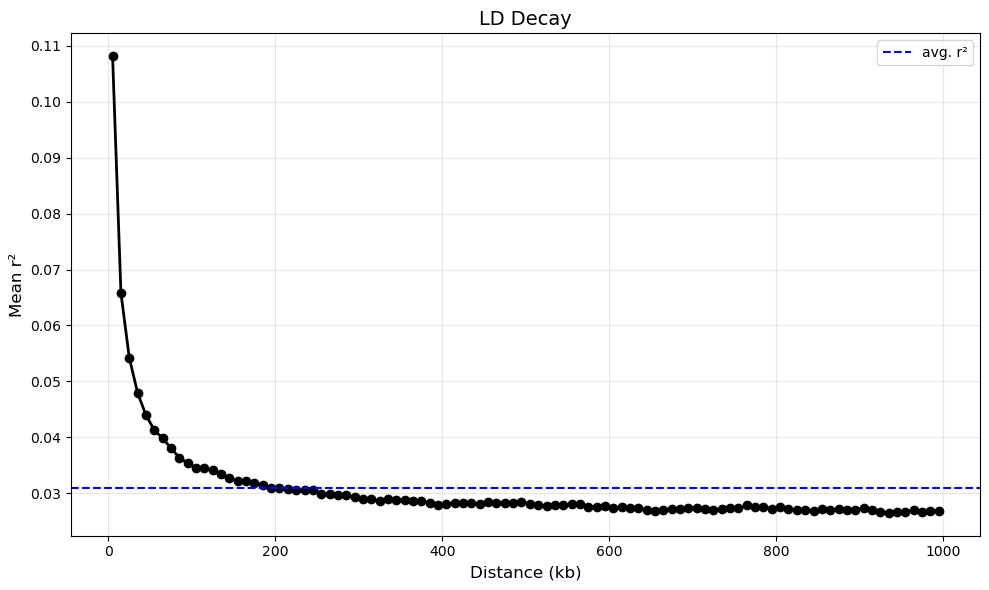

In [43]:
# make a histogram of the LD decay

num_bins = 100
# make num_bins over a maximum distance
bins = np.linspace(0, max_distance, num_bins+1)
bin_centers = (bins[1:] + bins[:-1])/2

mean_r2 = np.zeros((num_bins,))

# loop through the bins to sort the data by distance
for i in range(num_bins):
    # get the indices of the distances that fall within the bin
    in_bin = (distances >= bins[i]) & (distances < bins[i+1])
    # if there are any distances in the bin, calculate the mean
    if np.sum(in_bin) > 0:
        mean_r2[i] = np.nanmean(LD_values[in_bin])
    else:
        mean_r2[i] = np.nan

plt.figure(figsize=(10,6))
plt.plot(bin_centers/1000, mean_r2, 'o-', linewidth=2, color='black')
plt.axhline(y=np.nanmean(LD_values), color='blue', linestyle='--', label='avg. r²')
plt.xlabel('Distance (kb)', fontsize=12)
plt.ylabel('Mean r²', fontsize=12)
plt.title('LD Decay', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ld_decay.png', dpi=300)
plt.show()


/var/folders/47/3sc0r_t556988tw6r8vdy6d40000gp/T/ipykernel_85074/3669741369.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


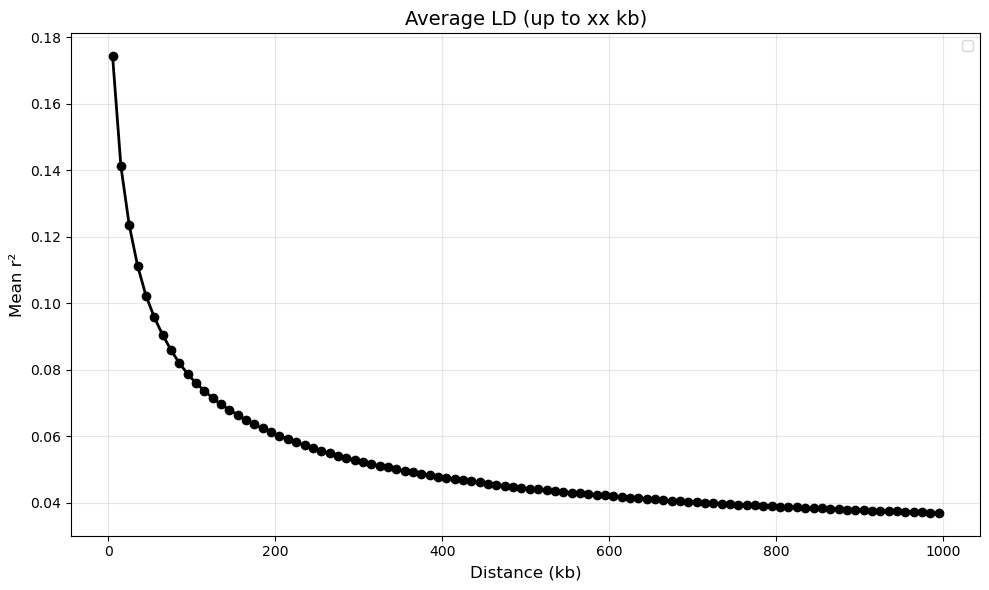

In [ ]:
# make a histogram of the LD decay
# but now, we calculate the mean r^2 up to a certain distance instead of within bins

num_bins = 100
# make num_bins over a maximum distance
bins = np.linspace(0, max_distance, num_bins+1)
bin_centers = (bins[1:] + bins[:-1])/2

mean_r2 = np.zeros((num_bins,))

# loop through the bins to sort the data by distance
for i in range(num_bins):
    # get the indices of the distances that fall within the bin
    below_bin = (distances < bins[i+1])
    # if there are any distances in the bin, calculate the mean
    if np.sum(below_bin) > 0:
        mean_r2[i] = np.nanmean(LD_values[below_bin])
    else:
        mean_r2[i] = np.nan

plt.figure(figsize=(10,6))
plt.plot(bin_centers/1000, mean_r2, 'o-', linewidth=2, color='black')
plt.xlabel('Distance (kb)', fontsize=12)
plt.ylabel('Mean r²', fontsize=12)
plt.title('Average LD (up to xx kb)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ld_decay_v2.png', dpi=300)
plt.show()


In [36]:
# Count how many nans
num_nans = np.sum(np.isnan(LD_values))
print(f"Number of NaN values: {num_nans}")
print(f"Total LD values: {len(LD_values)}")
print(f"Percentage NaN: {100 * num_nans / len(LD_values):.2f}%")

# Get the indices where nans occur
nan_indices = np.where(np.isnan(LD_values))[0]
print(f"\nFirst 10 indices with NaN: {nan_indices[:10]}")

# Check corresponding distances for those nans
if len(nan_indices) > 0:
    print(f"Distances at first 10 NaN locations: {distances[nan_indices[:10]]}")


# Check which bins have nans
for i in range(min(10, num_bins)):  # First 10 bins
    in_bin = (distances >= bins[i]) & (distances < bins[i+1])
    if np.sum(in_bin) > 0:
        num_nans_in_bin = np.sum(np.isnan(LD_values[in_bin]))
        print(f"Bin {i} ({bins[i]}-{bins[i+1]}): {num_nans_in_bin} nans out of {np.sum(in_bin)} values")


Number of NaN values: 10652066
Total LD values: 18056116
Percentage NaN: 58.99%

First 10 indices with NaN: [10 14 33 44 51 56 59 65 68 69]
Distances at first 10 NaN locations: [ 5938.  8852. 17378. 23482. 27780. 29258. 30386. 34160. 34705. 35292.]
Bin 0 (0.0-10000.0): 108841 nans out of 192038 values
Bin 1 (10000.0-20000.0): 110211 nans out of 190056 values
Bin 2 (20000.0-30000.0): 110888 nans out of 189431 values
Bin 3 (30000.0-40000.0): 111881 nans out of 189733 values
Bin 4 (40000.0-50000.0): 111131 nans out of 188873 values
Bin 5 (50000.0-60000.0): 111690 nans out of 188240 values
Bin 6 (60000.0-70000.0): 111657 nans out of 189250 values
Bin 7 (70000.0-80000.0): 111538 nans out of 188818 values
Bin 8 (80000.0-90000.0): 111733 nans out of 188036 values
Bin 9 (90000.0-100000.0): 111800 nans out of 187592 values
